# Supervisor Agent
Supervisor는 전체 흐름을 통제합니다.
- Request/Planner Agent: 요청을 분석하고 작업 계획을 세웁니다.
- Retrieval Agent: 계획에 맞춰 관련 정보를 모읍니다.
- Analysis Tool Agent: 모은 정보를 분석하고 요약합니다.
- Writer Agent: 분석 결과로 초안을 씁니다.
- Reviewer Agent: 초안을 검토합니다.
- Human Approval Node: 사용자가 승인하도록 최종 확인 후에 거절하면 다시 작성하도록 합니다.


## 패키지 설치


In [176]:
%pip install -q langchain langchain-openai langgraph pydantic


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: C:\Users\loveiori\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 출력 인코딩 설정


In [177]:
from typing import List
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from IPython.display import Image, display
from pathlib import Path
import json
import re
import sys

if sys.stdout.encoding and sys.stdout.encoding.lower().replace("-", "") != "utf8":
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
    sys.stderr.reconfigure(encoding="utf-8", errors="replace")


## Plan

- Planner는 단계와 검색 질의를 출력합니다.
- Reviewer는 피드백과 승인 여부를 결정합니다.


In [178]:
class Plan(BaseModel):
    """Request/Planner Agent가 생성하는 작업 계획

    주의: 중첩 객체 구조(PlanStep)는 gpt-oss 모델에서 구조화된 출력이
    불안정하므로, 단순한 List[str] 구조를 사용합니다.
    각 step 문자열은 "작업내용 (핵심: 키워드1, 키워드2)" 형식으로 작성합니다.
    """
    steps: List[str] = Field(
        description=(
            "사용자 요청을 처리하기 위한 순차적 작업 계획 (최소 2개, 최대 6개). "
            '각 단계는 "작업내용 (핵심: 키워드1, 키워드2)" 형식의 문자열입니다. '
            '예: "사용자 요청의 핵심 주제와 목적을 분석한다 (핵심: 요청 분석, 핵심 주제)"'
        ),
        min_length=2,
        max_length=6,
    )
    search_queries: List[str] = Field(
        description=(
            "Retrieval Agent가 사용할 검색 질의 목록 (최소 2개, 최대 5개). "
            "각 질의는 검색 엔진에 입력할 수 있는 명확한 한국어 문장 또는 키워드 조합입니다. "
            '예: "AI 에이전트 발전 과정"'
        ),
        min_length=2,
        max_length=5,
    )


class ReviewResult(BaseModel):
    """Reviewer Agent가 생성하는 검토 결과"""
    feedback: str = Field(description="초안에 대한 피드백/개선점")
    approved: bool = Field(description="초안이 품질 기준을 통과했는지 여부")


## LLM 객체 생성
- Local LLM Serving Backend에 접속하는 llm 객체를 생성
- Planner와 Reviewer는 `json_schema` 형식으로 출력하도록 설정합니다.


In [ ]:
llm_client = ChatOpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key="change_your_key", 
    model="openai/gpt-oss-20b",
)

planner_llm = llm_client.with_structured_output(Plan, method="json_schema")
reviewer_llm = llm_client.with_structured_output(ReviewResult, method="json_schema")


## Graph State

- 각 Node가 읽고 업데이트하는 State class를 정의합니다.
- `revision_count`로 재작성 횟수를 의미합니다.


In [180]:
class State(TypedDict):
    input: str
    plan: str
    search_queries: List[str]
    retrieved_docs: str
    analysis: str
    draft: str
    review_feedback: str
    review_approved: bool
    human_approved: bool
    final_output: str
    revision_count: int


### Request/Planner Agent


In [181]:
def request_planner_agent(state: State):
    system_prompt = (
        "당신은 요청 분석 및 계획 수립 전문가입니다.\n"
        "사용자의 요청을 분해하여 순차적으로 수행 가능한 작업 계획을 세우고, "
        "정보 검색에 사용할 검색 질의를 생성하세요.\n\n"
        "[출력 규칙]\n"
        "1. steps: 최소 2개, 최대 6개의 단계를 작성하세요.\n"
        '   각 단계는 "작업내용 (핵심: 키워드1, 키워드2)" 형식의 문자열입니다.\n'
        "   작업내용은 완결된 한국어 문장(10자 이상)으로 작성하세요.\n"
        "2. search_queries: 최소 2개, 최대 5개의 검색 질의를 작성하세요.\n"
        "   각 질의는 검색 엔진에 입력할 수 있는 명확한 한국어 문장 또는 키워드 조합이어야 합니다.\n"
        "   빈 문자열이나 의미 없는 문자(..., ???, ---)를 포함하지 마세요.\n\n"
        "[출력 예시]\n"
        "steps:\n"
        '  - "사용자 요청의 핵심 주제와 목적을 분석한다 (핵심: 요청 분석, 핵심 주제)"\n'
        '  - "관련 정보를 검색하여 수집한다 (핵심: 정보 검색, 자료 수집)"\n'
        "search_queries:\n"
        '  - "AI 에이전트 발전 과정"\n'
        '  - "AI 에이전트 향후 전망"'
    )

    result = planner_llm.invoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"사용자 요청: {state['input']}"),
        ]
    )
    return {
        "plan": result,
        "search_queries": result.search_queries,
    }


### Retrieval Agent


In [182]:
def retrieval_agent(state: State):
    queries = state.get("search_queries", [])
    queries_text = "\n".join(f"  - {q}" for q in queries)
    msg = llm_client.invoke(
        [
            SystemMessage(
                content=(
                    "당신은 정보 검색 에이전트입니다. "
                    "주어진 검색 질의들에 대해 관련성 높은 정보를 수집하여 정리하세요. "
                    "실제 검색 대신, 당신의 지식을 기반으로 각 질의에 대한 핵심 정보를 제공하세요."
                )
            ),
            HumanMessage(
                content=(
                    f"작업 계획:\n{state['plan']}\n\n"
                    f"검색 질의 목록:\n{queries_text}\n\n"
                    "각 질의에 대한 검색 결과를 정리해주세요."
                )
            ),
        ]
    )
    return {"retrieved_docs": msg.content}


### Analysis Tool Agent


In [183]:
def analysis_tool_agent(state: State):
    msg = llm_client.invoke(
        [
            SystemMessage(
                content=(
                    "당신은 데이터 분석 에이전트입니다. "
                    "검색된 정보를 분석하여 핵심 인사이트, 패턴, 통찰을 도출하고, "
                    "작성자가 보고서를 작성하는 데 활용할 수 있도록 정리하세요."
                )
            ),
            HumanMessage(
                content=(
                    f"원본 요청: {state['input']}\n\n"
                    f"작업 계획:\n{state['plan']}\n\n"
                    f"검색된 정보:\n{state['retrieved_docs']}\n\n"
                    "이 정보를 분석하여 핵심 인사이트를 도출해주세요."
                )
            ),
        ]
    )
    return {"analysis": msg.content}


### Writer Agent


In [184]:
def writer_agent(state: State):
    feedback = state.get("review_feedback", "")
    revision_count = state.get("revision_count", 0)
    system_prompt = (
        "당신은 전문 작성 에이전트입니다. "
        "분석 결과를 바탕으로 사용자의 요청에 부합하는 명확하고 체계적인 결과물을 작성하세요."
    )
    user_content = (
        f"원본 요청: {state['input']}\n\n"
        f"작업 계획:\n{state['plan']}\n\n"
        f"분석 결과:\n{state['analysis']}\n\n"
    )
    if feedback and revision_count > 0:
        user_content += (
            f"\n[이전 초안에 대한 검토 피드백 - 반드시 반영하여 개선하세요]\n"
            f"{feedback}\n\n"
            f"위 피드백을 반영하여 개선된 결과물을 작성하세요. (재작성 {revision_count}회차)"
        )
    msg = llm_client.invoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_content),
        ]
    )
    return {"draft": msg.content}


### Reviewer Agent


In [185]:
def reviewer_agent(state: State):
    result = reviewer_llm.invoke(
        [
            SystemMessage(
                content=(
                    "당신은 엄격한 검토자 에이전트입니다. "
                    "초안이 사용자의 원본 요청을 충족하는지, 내용이 정확하고 체계적인지 평가하세요. "
                    "명백한 결함이 없으면 approved=true로 설정하고, 개선이 필요하면 "
                    "approved=false와 함께 구체적인 피드백을 제공하세요."
                )
            ),
            HumanMessage(
                content=(
                    f"원본 요청: {state['input']}\n\n"
                    f"초안:\n{state['draft']}\n\n"
                    "초안을 검토하고 승인 여부를 결정해주세요."
                )
            ),
        ]
    )
    return {
        "review_feedback": result.feedback,
        "review_approved": result.approved,
    }


### Human Approval

- `interrupt()`에서 실행이 멈추고 사용자 승인 여부를 묻습니다.
- `Command(resume="...")`을 호출할 때 그래프를 깨웁니다.


In [186]:
def human_approval_node(state: State):
    print("\n" + "=" * 60)
    print("[Human Approval Node] 최종 결과물 검토 대기 중...")
    print("=" * 60)
    print(f"\n[원본 요청]\n{state['input']}")
    print(f"\n[작성된 결과물]\n{state['draft']}")
    print("\n" + "=" * 60)

    # interrupt로 실행을 멈추고 외부 입력을 대기합니다.
    user_decision = interrupt(
        {
            "question": "이 결과물을 승인하시겠습니까? (승인 시 'approve', 반려 시 구체적인 수정 요청사항 입력)",
            "draft": state["draft"],
            # "options": ["approve", "reject"],
        }
    )
    
    # resume으로 들어온 값이 'approve'면 최종 승인
    if user_decision == "approve":
        print("\n[Human Approval] 사용자가 승인했습니다.")
        return {
            "human_approved": True,
            "final_output": state["draft"],
        }
    # 'approve'가 아닌 다른 텍스트가 들어오면 '반려 사유(피드백)'로 간주합니다.
    else:
        # 입력값이 없거나 단순 reject일 경우를 대비한 기본 피드백 처리
        feedback = user_decision if isinstance(user_decision, str) and user_decision not in ["", "reject"] else "사용자가 결과물을 반려했습니다. 내용을 전반적으로 개선해주세요."
        
        print(f"\n[Human Approval] 사용자가 반려했습니다. 피드백: {feedback}")
        return {
            "human_approved": False,
            "review_feedback": f"[사용자 최종 반려 피드백] {feedback}", # 이 피드백이 Writer에게 전달됨
            "final_output": state["draft"], # 5회 거부 초과로 강제 종료 시 마지막 초안이라도 보존하기 위함
        }


## Supervisor Routing
- Review를 통과하면 Human Approval으로, 실패하면 Writer로 돌아갑니다.
- 재작성 횟수가 3회 이상이면, Human Approval로 강제 진행합니다.


In [187]:
def route_after_review(state: State) -> Literal["human_approval", "writer"]:
    if state.get("review_approved", False):
        return "human_approval"
    if state.get("revision_count", 0) >= 3:
        print("\n[Supervisor] 최대 재작성 횟수(3회) 도달 → Human Approval로 강제 진행")
        return "human_approval"
    print(f"\n[Supervisor] 검토 미통과 → Writer Agent로 재작성 지시 ({state.get('revision_count', 0) + 1}회차)")
    return "writer"


def route_after_human(state: State) -> Literal[END, "writer"]:
    if state.get("human_approved", False):
        return END
    revision_count = state.get("revision_count", 0)
    if revision_count >= 5:
        print("\n[Supervisor] 사용자 거부 횟수(5회) 초과 → 현재 결과물로 종료")
        return END
    print(f"\n[Supervisor] 사용자 거부 → Writer Agent로 재작성 지시 ({revision_count + 1}회차)")
    return "writer"


def increment_revision(state: State):
    return {"revision_count": state.get("revision_count", 0) + 1}


## 그래프 생성
- 각 노드들을 (조건부) 엣지로 연결하고 `MemorySaver`로 interrupt를 저장합니다.


In [188]:
supervisor_builder = StateGraph(State)

supervisor_builder.add_node("request_planner", request_planner_agent)
supervisor_builder.add_node("retrieval", retrieval_agent)
supervisor_builder.add_node("analysis", analysis_tool_agent)
supervisor_builder.add_node("increment_revision", increment_revision)
supervisor_builder.add_node("writer", writer_agent)
supervisor_builder.add_node("reviewer", reviewer_agent)
supervisor_builder.add_node("human_approval", human_approval_node)

supervisor_builder.add_edge(START, "request_planner")
supervisor_builder.add_edge("request_planner", "retrieval")
supervisor_builder.add_edge("retrieval", "analysis")
supervisor_builder.add_edge("analysis", "increment_revision")
supervisor_builder.add_edge("increment_revision", "writer")
supervisor_builder.add_edge("writer", "reviewer")

supervisor_builder.add_conditional_edges(
    "reviewer",
    route_after_review,
    {
        "human_approval": "human_approval",
        "writer": "increment_revision",
    },
)
supervisor_builder.add_conditional_edges(
    "human_approval",
    route_after_human,
    {
        END: END,
        "writer": "increment_revision",
    },
)

checkpointer = MemorySaver()
supervisor_workflow = supervisor_builder.compile(checkpointer=checkpointer)


## Workflow 시각화


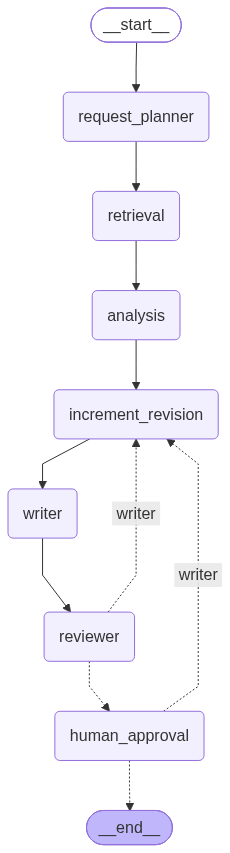

saved Supervisor.png


In [189]:
png = supervisor_workflow.get_graph().draw_mermaid_png()
Path("Supervisor.png").write_bytes(png)
display(Image(data=png))
print("saved Supervisor.png")


## Workflow 실행

In [190]:
# =========================================================
# 1. 초기 상태 설정
# =========================================================
initial_state = {
    "input": "AI 에이전트의 발전 과정과 향후 전망에 대한 보고서를 작성해줘",
    "revision_count": 0,
}


print("워크플로우 최초 실행 시작...\n")
config = {"configurable": {"thread_id": "supervisor-agent"}}
result = supervisor_workflow.invoke(initial_state, config=config)


# =========================================================
# 2. 대화형 인터럽트 처리 루프
# =========================================================
# 워크플로우가 완전히 끝날(END) 때까지 계속 반복합니다.
while True:
    # 현재 그래프의 상태를 가져옵니다.
    state_snapshot = supervisor_workflow.get_state(config)
    
    # state_snapshot.next 값이 없다면(빈 튜플이면) 그래프가 최종 종료(END)된 것입니다.
    if not state_snapshot.next:
        break
        
    # next 값이 있다면(어딘가 멈춰있다면), human_approval_node의 interrupt 상태입니다.
    current_values = state_snapshot.values
    print("\n" + "=" * 60)
    print(f"[초안 대기 중] 현재 draft 길이: {len(current_values.get('draft', ''))}자")
    print(f"[재작성 횟수]: {current_values.get('revision_count', 0)}회")
    print("=" * 60)
    
    # 주피터 노트북 하단에 입력창(프롬프트)을 생성합니다.
    user_decision = input(
        "\n결과물을 승인하시겠습니까?\n"
        "(승인하려면 'approve' 입력, 반려하려면 구체적인 수정 요청사항 입력): "
    )
           
    print(f"\n입력된 내용: {user_decision}")
    print("워크플로우 재개 중...\n")
    
    # 사용자의 입력값(승인 또는 수정사항)을 전달하여 그래프를 다시 깨웁니다.
    supervisor_workflow.invoke(Command(resume=user_decision), config=config)


# =========================================================
# 3. 최종 결과 확인
# =========================================================
# 최종 상태값을 다시 가져옵니다.
final_result = supervisor_workflow.get_state(config).values

print("\n" + "=" * 60)
print("\n최종 완료!")
print(f"사용자 최종 승인 여부: {final_result.get('human_approved')}")
print(f"총 재작성 횟수: {final_result.get('revision_count')}")
print("\n[최종 결과물]")
print("=" * 60)
print(final_result.get("final_output"))

워크플로우 최초 실행 시작...


[Human Approval Node] 최종 결과물 검토 대기 중...

[원본 요청]
AI 에이전트의 발전 과정과 향후 전망에 대한 보고서를 작성해줘

[작성된 결과물]
# AI 에이전트 발전 과정과 향후 전망  
(2026년 10월 현재)

> **목적** – AI 에이전트가 생겨난 이래 정의(개념)부터 현재 연구·산업 동향까지 요약하고, 2030년까지의 시장·경제 효과와 정책·기술 이슈를 통합적으로 정리합니다.  
> **대상** – AI·ML 연구자, AI 솔루션 개발자, 투자자, 기업 전략 담당자, 정책 입안자

> **문서 길이**: 약 18–22 페이지(3–5 페이지 ≈ 1 A4). 차트·그래프를 포함한 최종본은 < 25 페이지 미만이 권장됩니다.

| 페이지 | 주요 내용 | 트랜지션 포인트 |
|-------|-----------|-----------------|
| 1 | 표지·목차 |  |
| 2-3 | 서론(배경·목적·범위) |  |
| 4-5 | AI 에이전트 정의·개념 | 시각적 흐름(상태–행동–보상) |
| 6-9 | 역사 & 진화 단계 | 타임라인(1970‑2024) |
| 10-11 | 2024 최신 연구 동향 | 기술‑클러스터(멀티모달, Edge, Meta‑Learning) |
| 12-13 | 시장 규모·성장 동력 | CAGR 24%·플랫폼 KPI(엔터프라이즈 vs 소비자) |
| 14-16 | 응용 분야·경제적 영향 | ROI 예시, 노동시장 모델(생산성↑15‑20%) |
| 17 | 핵심 과제 & 리스크 매트릭스 | 프라이버시·보안·규제 |
| 18-19 | 향후 전망 & 전략적 제언 | 2030년 시나리오·전략 |
| 20 | 결론 |  |
| 21 | 참고문헌 |  |
| 22 | 부록(데이터사전, 설문) | 가이드라인 |

> ※(페이지 단위 예시는 개시형 문서라면 필요에 따라 2~4 페이지 안팎으로 축소 가능)

---

## 1. 서론

### 1‑1. 연구 배경
- **디지털 